In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import sys
import matplotlib.pyplot as plt 
import pandas as pd 
sys.path.insert(1, '../')

In [2]:
import pyFBS

## Basic example of System Equivalent Modal Mixing (SEMM) 
With SEMM numerical and experimental model can be coupled to form a hybrid model. The interface connection betwen the two models is defined with an overlay parameter.

#### Importing FEM and experimental data

In [3]:
freq_n,Y_num = np.load("../data/LADISK_simple_beam/FEM/Y_FEM.npy",allow_pickle = True)

Y_num = Y_num*-1*(2*np.pi*freq_n)**2
Y_num = Y_num.T

freq_e,Y_data = np.load("../data/LADISK_simple_beam/Measurements/test_data.npy",allow_pickle = True)
Y_exp = Y_data[2,:-1,:]


#Y_exp[:,1:] /= 2*np.pi*freq_e[1:]
Y_val = Y_data[2,-1,1:]#/(2*np.pi*freq_e[1:])

In [4]:
Y_num.shape

(6000, 50, 50)

Plot both datasets

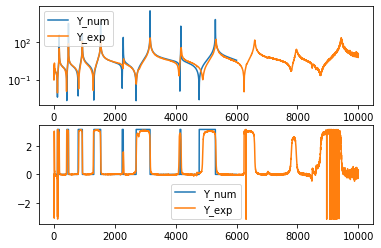

In [5]:
plt.figure()

plt.subplot(211)
plt.semilogy(freq_n, np.abs(Y_num[:, 21, 21]),label = "Y_num");
plt.semilogy(freq_e, np.abs(Y_exp[2,:]),label = "Y_exp");
plt.legend()

plt.subplot(212)
plt.plot(freq_n, np.angle(Y_num[:, 21, 21]),label = "Y_num");
plt.plot(freq_e, np.angle(Y_exp[2,:]),label = "Y_exp");
plt.legend()

Define locations in the data matrix

array([ 5, 13, 21, 30, 38, 46])

array([16])

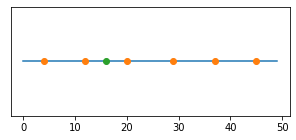

In [6]:
Y_exp = Y_exp[:,1:6001].T
freq = freq_e[1:6001]


loc_dof = np.asarray([50,150,250,350,450,550])*50/600
loc_dof = loc_dof.astype(int)

loc_dof_ref = np.asarray([200])*50/600
loc_dof_ref = loc_dof_ref.astype(int)

plt.figure(figsize = (5,2))
plt.plot(range(50),[0]*50)
plt.plot(loc_dof,[0]*6,'o')
plt.plot(loc_dof_ref,0,'o')

plt.yticks([])
display(loc_dof+1)
display(loc_dof_ref)


Check the shape of datasets

In [7]:
display(Y_num.shape)
display(Y_exp.shape)

(6000, 50, 50)

(6000, 6)

Define the overlay model

In [8]:
Overlay=[[[5 ,  21], [1, 1], [1]],
         [[13,  21], [1, 1], [2]],
         [[21,  21], [1, 1], [3]],
         [[30,  21], [1, 1], [4]],
         [[38,  21], [1, 1], [5]],
         [[46,  21], [1, 1], [6]],]

display(pd.DataFrame(Overlay))

,0,1,2
0,"[5, 21]","[1, 1]",[1]
1,"[13, 21]","[1, 1]",[2]
2,"[21, 21]","[1, 1]",[3]
3,"[30, 21]","[1, 1]",[4]
4,"[38, 21]","[1, 1]",[5]
5,"[46, 21]","[1, 1]",[6]


Apply different SEMM methodologies

In [9]:
%%time
Y_SEMM = pyFBS.SEMM(Y_num,Y_exp,Overlay,DoF = 1)

Wall time: 12.7 s


In [10]:
%%time
Y_SEMM_svd = pyFBS.SEMM(Y_num,Y_exp,Overlay,DoF = 1,SEMM_type = "fully-extended-svd",red_comp = 5)

Wall time: 13.4 s


Check random FRF

(-3.5, 3.5)

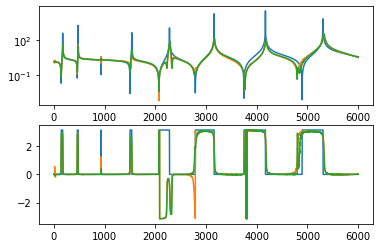

In [11]:
sel_i = 45
sel_j = 45
plt.figure()
plt.subplot(211)
plt.semilogy(freq,np.abs(Y_num[:,sel_i,sel_j]))
plt.semilogy(freq,np.abs(Y_SEMM[:,sel_i,sel_j]))
plt.semilogy(freq,np.abs(Y_SEMM_svd[:,sel_i,sel_j]))


plt.subplot(212)
plt.plot(freq,np.angle(Y_num[:,sel_i,sel_j]))
plt.plot(freq,np.angle(Y_SEMM[:,sel_i,sel_j]))
plt.plot(freq,np.angle(Y_SEMM_svd[:,sel_i,sel_j]))
plt.ylim(-3.5,3.5)

Side-by-side comparison with validation measurements

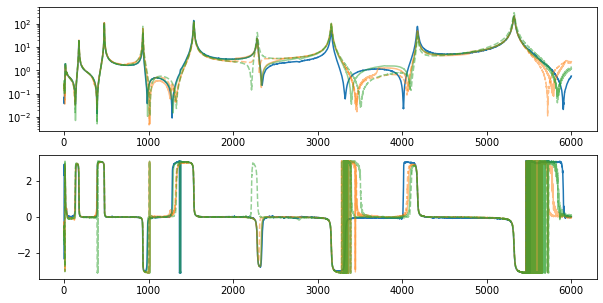

In [12]:
plt.figure(figsize = (10,5))
plt.subplot(211)
plt.semilogy(freq,np.abs(Y_val[1:6001]))
plt.semilogy(freq,np.abs(Y_SEMM_svd[:,16,20]),color = "tab:orange",alpha  =.5)
plt.semilogy(freq,np.abs(Y_SEMM_svd[:,20,16]),'--',color = "tab:orange",alpha  =.5)

plt.semilogy(freq,np.abs(Y_SEMM[:,16,20]),color = "tab:green",alpha  =.5)
plt.semilogy(freq,np.abs(Y_SEMM[:,20,16]),'--',color = "tab:green",alpha  =.5)

#plt.semilogy(freq,np.abs(Y_SEMM[:,16,21-1]))


plt.subplot(212)
plt.plot(freq,np.angle(Y_val[1:6001]))
plt.plot(freq,np.angle(Y_SEMM_svd[:,16,20]),color = "tab:orange",alpha  =.5)
plt.plot(freq,np.angle(Y_SEMM_svd[:,20,16]),'--',color = "tab:orange",alpha  =.5)

plt.plot(freq,np.angle(Y_SEMM[:,16,20]),color = "tab:green",alpha  =.5)
plt.plot(freq,np.angle(Y_SEMM[:,20,16]),'--',color = "tab:green",alpha  =.5)

Check the reciprocity

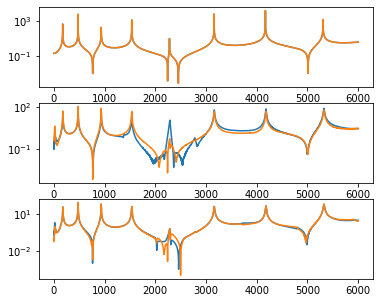

In [27]:
sel_i = 3
sel_j = 30

plt.figure(figsize= (6,5))

plt.subplot(311)
plt.semilogy(freq,np.abs(Y_num[:,sel_i,sel_j]))
plt.semilogy(freq,np.abs(Y_num[:,sel_j,sel_i]))

plt.subplot(312)
plt.semilogy(freq,np.abs(Y_SEMM[:,sel_i,sel_j]))
plt.semilogy(freq,np.abs(Y_SEMM[:,sel_j,sel_i]))

plt.subplot(313)
plt.semilogy(freq,np.abs(Y_SEMM_svd[:,sel_i,sel_j]))
plt.semilogy(freq,np.abs(Y_SEMM_svd[:,sel_j,sel_i]))


Check the reciprocity of the hybrid model

In [28]:
def coh_frf(h_num, h_exp,check = False):
    """
    :param h_num: numerični kompleksni vektor FRF
    :param h_exp: eksperimentalni kompleksni vektor FRF
    
    :return: vrednost coherence kriterija
    """
    
    h_numk = np.conjugate(h_num)
    h_expk = np.conjugate(h_exp)
    
    def vector(h_, h_K):
        """
        :param h_: kompleksni vektor FRF
        :param h_K: konjugirani kompleksni vektor FRF
        
        :return: vektorski produkt
        """
        
        vec = np.dot(h_, h_K)
        return vec

    coh = (h_num + h_exp)
    
    coh = np.abs(vector((h_num + h_exp), (h_numk + h_expk)))  / 2 / (vector(h_numk, h_num)+vector(h_expk, h_exp))
    coh_abs = np.abs(coh)
    
    if check:
        return coh,coh_abs
    else:
        return coh_abs

In [29]:
Y_SEMM_coh = np.zeros((50,50))
Y_SEMM_svd_coh = np.zeros((50,50))

for i in range(50):
    for j in range(50):
        Y_SEMM_coh[i,j] = coh_frf(Y_SEMM[:,i,j], Y_SEMM[:,j,i])
        Y_SEMM_svd_coh[i,j] = coh_frf(Y_SEMM_svd[:,i,j], Y_SEMM_svd[:,j,i])

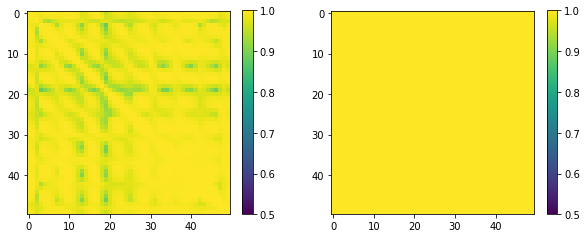

In [30]:
plt.figure(figsize = (10,5))
plt.subplot(121)
plt.imshow(Y_SEMM_coh)
plt.clim(0.5,1)
plt.colorbar(shrink =.75)

plt.subplot(122)
plt.imshow(Y_SEMM_svd_coh)
plt.clim(0.5,1)
plt.colorbar(shrink =.75);

In [31]:
print(np.mean(Y_SEMM_coh))
print(np.mean(Y_SEMM_svd_coh))

0.986183135349714
0.9998998479952236
